In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform
#from torchvision import datasets, transforms, utils
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.model_selection import ParameterSampler, RandomizedSearchCV, cross_val_score
#from scipy.stats import uniform
from retriever import *
import random
np.random.seed(32)
random.seed(32)
import skopt
from skopt import gp_minimize
from sklearn.model_selection import ParameterSampler, cross_val_score

### Bayesian optimization

In [51]:
#Setup

altitude_range = (8, 12.7)
latitude_range = (54.5, 57.8)

domain = {
    "latitude": latitude_range,
    "altitude": altitude_range,
}

x0 = [np.random.choice(latitude_range),np.random.choice(altitude_range)]
y0 = request_elevation(x0[0],x0[1])

In [59]:
global i
i = 1
# What we want to maximize
def objective_function(x): 
    
    elevation = request_elevation(x[0],x[1])
    global i
    i += 1
    print(f"\n\n index = {i}, x = {x}, elevation = {elevation}")

    
    return - elevation


np.int = int #numpy np.int deprecation workaround

opt = gp_minimize(objective_function, # the function to minimize
                  [latitude_range, altitude_range],
                                      # the bounds on each dimension of x
                  acq_func="EI",      # the acquisition function
                  n_initial_points=0, # no initial point except the one
                  n_calls=49,         # the number of evaluations of objective_function 19 since we give one initial point
                  x0=x0,           #initial point
                  y0=[y0],           #inital objective function value
                  xi=0.1,             #exploration parameter
                  noise=0.01**2)       # the noise level (optional)



 index = 2, x = [54.5, 8.0], elevation = -15.15555572509766


 index = 3, x = [54.50067204708638, 8.035473739629248], elevation = -14.94414234161377


 index = 4, x = [55.173819530821156, 12.7], elevation = -27.07111167907715


 index = 5, x = [54.669511303724775, 12.7], elevation = -19.52168846130371


 index = 6, x = [54.5, 12.7], elevation = -10


 index = 7, x = [56.0317687476423, 12.7], elevation = 4.070961952209473


 index = 8, x = [56.34393070065793, 12.7], elevation = -7.485222816467285


 index = 9, x = [56.01058748440591, 8.0], elevation = -19.83256340026855


 index = 10, x = [55.9086640137748, 12.7], elevation = 38.10655975341797


 index = 11, x = [55.715785452116556, 12.7], elevation = -6.569530010223389


 index = 12, x = [56.7485194116707, 12.7], elevation = 18.98139953613281


 index = 13, x = [55.8687480922723, 12.7], elevation = -8.040968894958496


 index = 14, x = [55.931030239522954, 12.7], elevation = -5.497796058654785


 index = 15, x = [56.70569961510053, 1

In [60]:
y_bo = np.maximum.accumulate(-opt.func_vals).ravel()
y_bo

array([-170.45568848,  -15.15555573,  -14.94414234,  -14.94414234,
        -14.94414234,  -10.        ,    4.07096195,    4.07096195,
          4.07096195,   38.10655975,   38.10655975,   38.10655975,
         38.10655975,   38.10655975,   38.10655975,   45.97245026,
         45.97245026,   45.97245026,   45.97245026,   45.97245026,
         45.97245026,   45.97245026,   45.97245026,   45.97245026,
         45.97245026,   45.97245026,   45.97245026,   93.77630615,
         93.77630615,   93.77630615,  108.44143677,  120.67938232,
        120.90921021,  120.90921021,  120.90921021,  120.90921021,
        120.90921021,  120.90921021,  120.90921021,  120.90921021,
        120.90921021,  120.90921021,  120.90921021,  120.90921021,
        120.90921021,  120.90921021,  120.90921021,  120.90921021,
        120.90921021,  120.90921021])

In [61]:
-opt.func_vals.ravel()

array([-1.70455688e+02, -1.51555557e+01, -1.49441423e+01, -2.70711117e+01,
       -1.95216885e+01, -1.00000000e+01,  4.07096195e+00, -7.48522282e+00,
       -1.98325634e+01,  3.81065598e+01, -6.56953001e+00,  1.89813995e+01,
       -8.04096889e+00, -5.49779606e+00,  1.09582443e+01,  4.59724503e+01,
       -1.95561063e+00, -1.85747528e+01,  4.19423332e+01, -2.51458473e+01,
       -3.16672993e+00, -0.00000000e+00, -2.80000000e+01, -1.20221905e-01,
       -6.41918802e+00,  2.33210945e+01, -2.00000000e+00,  9.37763062e+01,
        9.30429916e+01,  6.46681366e+01,  1.08441437e+02,  1.20679382e+02,
        1.20909210e+02,  9.85566177e+01,  1.02922096e+02,  1.07701675e+02,
        6.89390182e+01,  9.99174728e+01,  1.09412285e+02,  1.17954643e+02,
        1.13116440e+02,  1.00577538e+02,  5.90077400e+01,  7.63580933e+01,
        7.62983627e+01,  8.69659729e+01,  4.18083649e+01,  7.65666962e+01,
        6.87346954e+01,  9.32520218e+01])

In [66]:
altitude_range = (8, 12.7)
latitude_range = (54.5, 57.8)

domain = {
    "latitude": uniform(loc=54.5, scale=57.8 - 54.5),  # full latitude_range
    "altitude": uniform(loc=8, scale=12.7 - 8),        # full altitude_range
}

param_list = list(ParameterSampler(domain,n_iter=50,random_state=32))
print(param_list)

[{'altitude': np.float64(12.036779556277285), 'latitude': np.float64(55.72994681141842)}, {'altitude': np.float64(10.609105256593404), 'latitude': np.float64(57.65366661167283)}, {'altitude': np.float64(11.46234711065275), 'latitude': np.float64(57.193476959071184)}, {'altitude': np.float64(8.475106833450536), 'latitude': np.float64(57.56401063234619)}, {'altitude': np.float64(10.862813094259153), 'latitude': np.float64(56.46862633920681)}, {'altitude': np.float64(8.43138543354215), 'latitude': np.float64(55.63911460290768)}, {'altitude': np.float64(11.11493685897226), 'latitude': np.float64(55.95765451192208)}, {'altitude': np.float64(10.591992596051615), 'latitude': np.float64(56.82225122170937)}, {'altitude': np.float64(10.770185787117123), 'latitude': np.float64(54.6647781060713)}, {'altitude': np.float64(10.640421647693545), 'latitude': np.float64(57.028982958834895)}, {'altitude': np.float64(12.281269149438472), 'latitude': np.float64(54.80660282456536)}, {'altitude': np.float64(

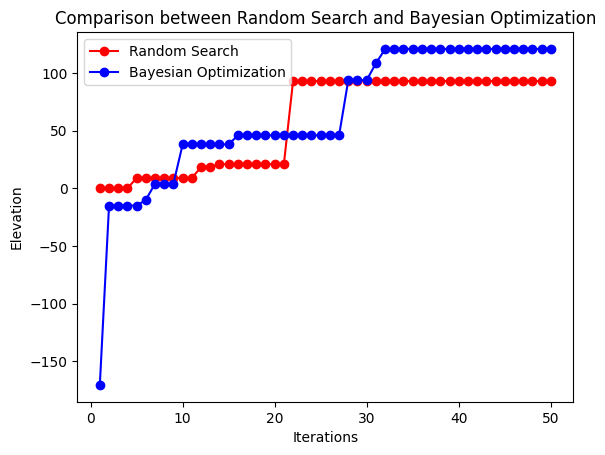

In [67]:
random_elevation = []
for param in param_list:
    random_elevation.append(request_elevation(param["latitude"],param["altitude"]))

max_cumulative_elevation_per_iteration = np.maximum.accumulate(random_elevation)
y_bo = np.maximum.accumulate(-opt.func_vals).ravel()
# define iteration number
xs = np.arange(1,len(random_elevation) + 1,1)


plt.plot(xs, max_cumulative_elevation_per_iteration, 'o-', color = 'red', label='Random Search')
plt.plot(xs, y_bo, 'o-', color = 'blue', label='Bayesian Optimization')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Elevation')
plt.title('Comparison between Random Search and Bayesian Optimization')
plt.show()

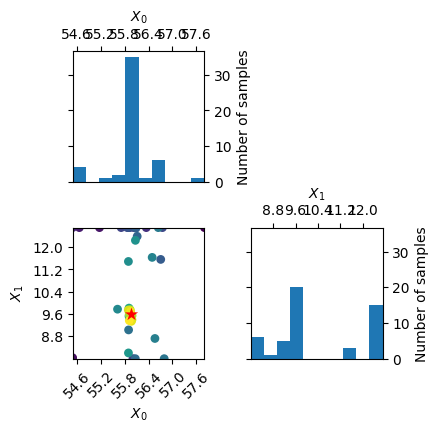

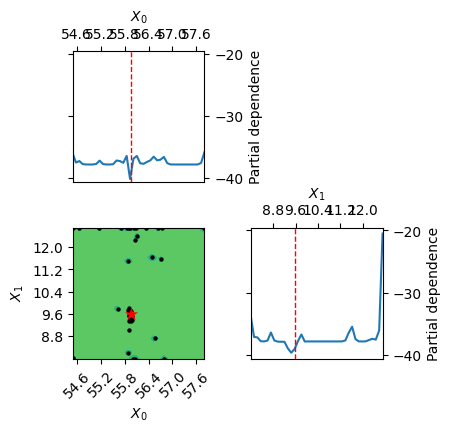

In [68]:
from skopt.plots import plot_objective, plot_evaluations

# 1. Shows where the optimizer spent most of its time
plot_evaluations(opt, bins=10)
plt.show()

# 2. Shows the predicted landscape (the surrogate model)
plot_objective(opt)
plt.show()

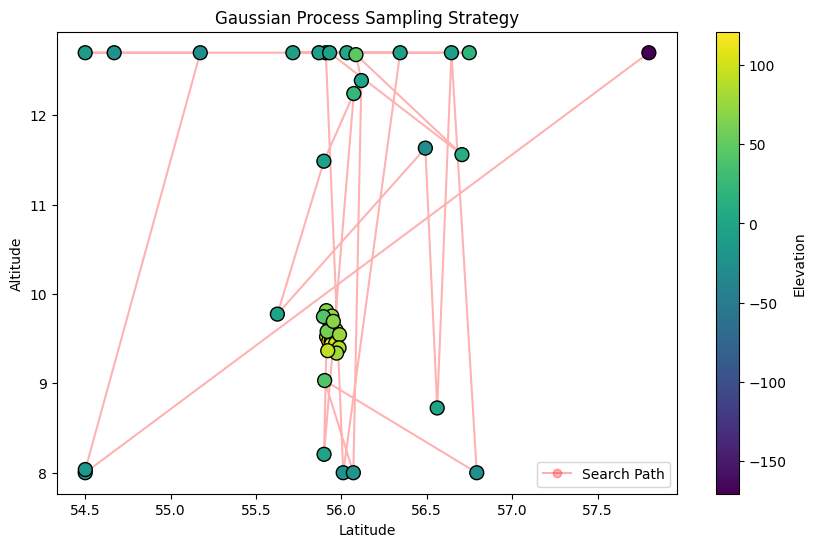

In [69]:
import matplotlib.pyplot as plt

# Extract the points sampled (x) and the results (y)
# opt.x_iters is a list of [lat, alt] pairs
# opt.func_vals is the elevation (negative because of the objective function)
sampled_points = np.array(opt.x_iters)
elevations = -opt.func_vals  # Convert back to positive elevation

plt.figure(figsize=(10, 6))
# Plot the path of the optimizer
plt.plot(sampled_points[:, 0], sampled_points[:, 1], 'ro-', alpha=0.3, label='Search Path')
# Scatter plot colored by elevation to see where the high points are
sc = plt.scatter(sampled_points[:, 0], sampled_points[:, 1], 
                 c=elevations, cmap='viridis', s=100, edgecolors='k', zorder=5)

plt.colorbar(sc, label='Elevation')
plt.xlabel('Latitude')
plt.ylabel('Altitude')
plt.title('Gaussian Process Sampling Strategy')
plt.legend()
plt.show()